# Framing Hit Analysis

Notebook for hit-level framing analysis.

In [6]:
import pandas as pd
from pathlib import Path

csv_path = Path("/Users/katinkakurz/projects/Thesis/2a_NER/outputs/framing_gpt_results.csv")

df = pd.read_csv(csv_path)

print(f"Loaded {len(df):,} rows from {csv_path}")
display(df.head())

Loaded 11,973 rows from /Users/katinkakurz/projects/Thesis/2a_NER/outputs/framing_gpt_results.csv


,hit_id,row_id,source,Title,hit_text,context_idx,count_hits,count_unique_entities,context_window,model,response_id,category,evidence,raw_response_json
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Politico,1,1,1,"Er hat es geschafft, seine Leute überall zu pl...",gpt-5-mini,resp_0e3ba66f85f590500069c4635798988194bf13317...,NEUTRAL,NaN,"{""id"": ""resp_0e3ba66f85f590500069c463579898819..."
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Bild-Zeitung,1,1,1,Viele haben Reitschuster aus der Corona-Zeit j...,gpt-5-mini,resp_05d159969059d7ad0069c4635784cc81938df21e9...,DISINFORMATION/FALSCHDARSTELLUNG,Propagandisten von Bild-Zeitung,"{""id"": ""resp_05d159969059d7ad0069c4635784cc819..."
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,1,1,1,Der Spiegel macht mal wieder Berichterstattung...,gpt-5-mini,resp_084a85555116e7270069c4635799bc81949029652...,VERSAGEN/INKOMPETENZ,Berichterstattung für den Kindergarten,"{""id"": ""resp_084a85555116e7270069c4635799bc819..."
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,2,1,1,Das NABU ist das vielleicht wichtigste Instrum...,gpt-5-mini,resp_067c239f074dd8230069c46357985c8193befbad9...,NEUTRAL,NaN,"{""id"": ""resp_067c239f074dd8230069c46357985c819..."
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,3,4,1,"Ich denke, die Antwort liegt auf der Hand. Mär...",gpt-5-mini,resp_0f30c6857a242fb20069c463578cd0819496d5c8e...,POSITIONS-/PARTEILICHKEITS-BIAS,anti-russischen und pro-ukrainischen Propagand...,"{""id"": ""resp_0f30c6857a242fb20069c463578cd0819..."


### Data Exploration - Framing Results

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df["source"] = df["source"].fillna("unknown").astype(str).str.strip()
df["category"] = df["category"].fillna("missing").astype(str).str.strip()

category_order = [
    "POSITIONS-/PARTEILICHKEITS-BIAS",
    "VERZERRUNG/MANIPULATION",
    "DISINFORMATION/FALSCHDARSTELLUNG",
    "VERSAGEN/INKOMPETENZ",
    "NEUTRAL",
    "IRRELEVANT",
]

source_order = df["source"].value_counts().index.tolist()

print(f"Rows: {len(df):,}")
display(df.head())


Rows: 11,973


,hit_id,row_id,source,Title,hit_text,context_idx,count_hits,count_unique_entities,context_window,model,response_id,category,evidence,raw_response_json
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Politico,1,1,1,"Er hat es geschafft, seine Leute überall zu pl...",gpt-5-mini,resp_0e3ba66f85f590500069c4635798988194bf13317...,NEUTRAL,NaN,"{""id"": ""resp_0e3ba66f85f590500069c463579898819..."
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Bild-Zeitung,1,1,1,Viele haben Reitschuster aus der Corona-Zeit j...,gpt-5-mini,resp_05d159969059d7ad0069c4635784cc81938df21e9...,DISINFORMATION/FALSCHDARSTELLUNG,Propagandisten von Bild-Zeitung,"{""id"": ""resp_05d159969059d7ad0069c4635784cc819..."
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,1,1,1,Der Spiegel macht mal wieder Berichterstattung...,gpt-5-mini,resp_084a85555116e7270069c4635799bc81949029652...,VERSAGEN/INKOMPETENZ,Berichterstattung für den Kindergarten,"{""id"": ""resp_084a85555116e7270069c4635799bc819..."
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,2,1,1,Das NABU ist das vielleicht wichtigste Instrum...,gpt-5-mini,resp_067c239f074dd8230069c46357985c8193befbad9...,NEUTRAL,NaN,"{""id"": ""resp_067c239f074dd8230069c46357985c819..."
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,3,4,1,"Ich denke, die Antwort liegt auf der Hand. Mär...",gpt-5-mini,resp_0f30c6857a242fb20069c463578cd0819496d5c8e...,POSITIONS-/PARTEILICHKEITS-BIAS,anti-russischen und pro-ukrainischen Propagand...,"{""id"": ""resp_0f30c6857a242fb20069c463578cd0819..."


In [8]:
overall_category_counts = (
    df["category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
    .rename_axis("category")
    .reset_index(name="n")
)

overall_category_counts["pct"] = overall_category_counts["n"] / overall_category_counts["n"].sum() * 100
display(overall_category_counts.round(2))


,category,n,pct
0,POSITIONS-/PARTEILICHKEITS-BIAS,1409,11.77
1,VERZERRUNG/MANIPULATION,1084,9.05
2,DISINFORMATION/FALSCHDARSTELLUNG,377,3.15
3,VERSAGEN/INKOMPETENZ,322,2.69
4,NEUTRAL,8568,71.56
5,IRRELEVANT,213,1.78


In [9]:
category_by_source_counts = pd.crosstab(
    df["source"],
    df["category"],
).reindex(index=source_order, columns=category_order, fill_value=0)

display(category_by_source_counts)
category_by_source_pct = (
    category_by_source_counts
    .div(category_by_source_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

display(category_by_source_pct)


category,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ,NEUTRAL,IRRELEVANT
source,,,,,,
Tagesschau,31,13,5,5,4281,35
Tichys_Einblick,594,373,124,163,979,49
Nius,362,296,108,91,1127,42
RT_de,172,160,43,23,1433,31
Antispiegel,75,163,45,26,223,8
Compact,81,58,34,9,283,47
Deutschlandkurier,94,21,18,5,242,1


category,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ,NEUTRAL,IRRELEVANT
source,,,,,,
Tagesschau,0.71,0.30,0.11,0.11,97.96,0.80
Tichys_Einblick,26.03,16.35,5.43,7.14,42.90,2.15
Nius,17.87,14.61,5.33,4.49,55.63,2.07
RT_de,9.24,8.59,2.31,1.24,76.96,1.66
Antispiegel,13.89,30.19,8.33,4.81,41.30,1.48
Compact,15.82,11.33,6.64,1.76,55.27,9.18
Deutschlandkurier,24.67,5.51,4.72,1.31,63.52,0.26


<Figure size 1200x700 with 0 Axes>

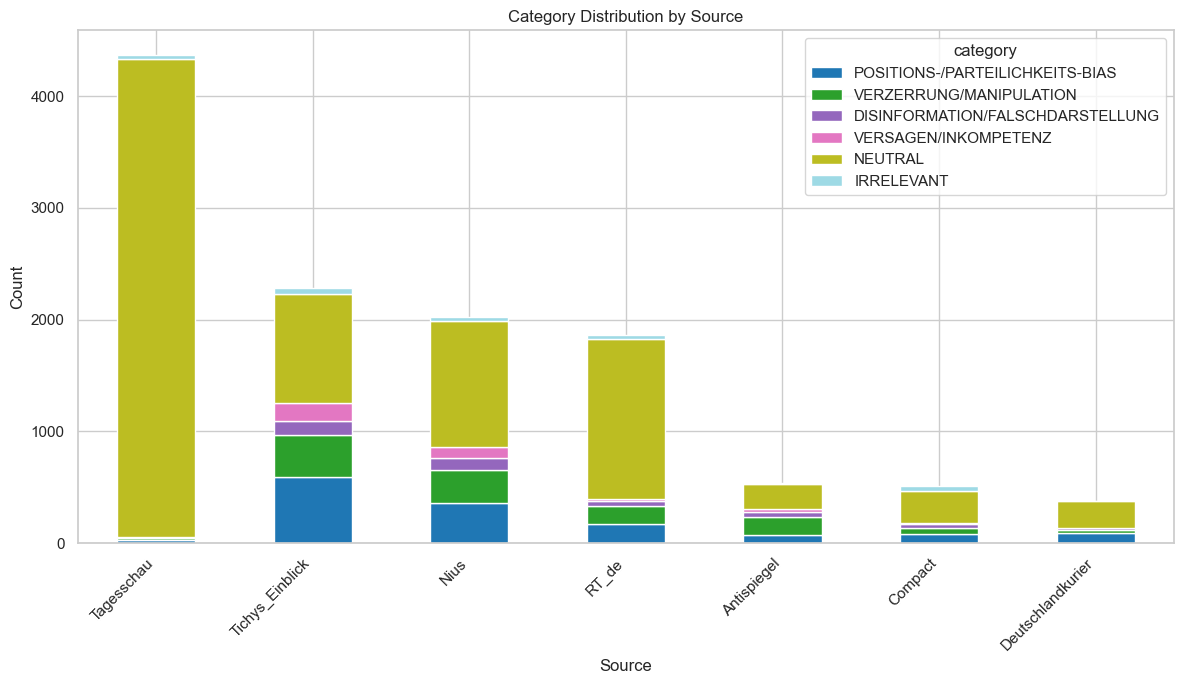

In [10]:
plt.figure(figsize=(12, 7))
category_by_source_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    colormap="tab20"
)
plt.title("Category Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Total corpus articles: 20,440
Articles mentioning mainstream media: 7,204 (35.2% of corpus articles)
Articles with bias: 1,668 (23.2% of articles mentioning mainstream media)
Total entity hits: 11,973
Non-neutral frames: 3,192


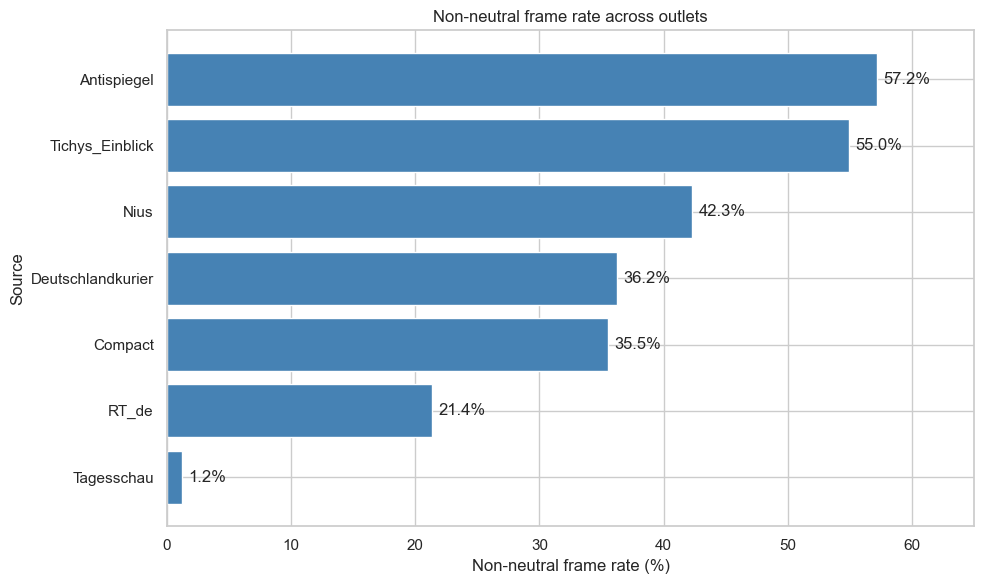

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load
framing_path = Path("/Users/katinkakurz/projects/Thesis/2a_NER/outputs/framing_gpt_results.csv")
corpus_path = Path("/Users/katinkakurz/projects/Thesis/data/raw/df_combined.csv")

df = pd.read_csv(framing_path).copy()
corpus_df = pd.read_csv(corpus_path, usecols=["row_id"]).copy()

# Clean
df["source"] = df["source"].fillna("unknown").astype(str).str.strip()
df["category"] = df["category"].fillna("missing").astype(str).str.strip()
df["hit_text"] = df["hit_text"].fillna("").astype(str).str.strip()

NON_NEUTRAL_EXCLUDE = {"NEUTRAL", "IRRELEVANT"}
df["is_non_neutral"] = ~df["category"].isin(NON_NEUTRAL_EXCLUDE)

# KPIs
total_corpus_articles = corpus_df["row_id"].nunique()
articles_mentioning_mainstream_media = df["row_id"].nunique()
articles_with_bias = df.loc[df["is_non_neutral"], "row_id"].nunique()

pct_articles_with_mentions = (
    articles_mentioning_mainstream_media / total_corpus_articles * 100
    if total_corpus_articles > 0 else 0
)

pct_articles_with_bias_given_mentions = (
    articles_with_bias / articles_mentioning_mainstream_media * 100
    if articles_mentioning_mainstream_media > 0 else 0
)

total_entity_hits = len(df)
non_neutral_frames = int(df["is_non_neutral"].sum())

# Source-level rates
source_stats = (
    df.groupby("source")
    .agg(
        total_hits=("category", "size"),
        non_neutral_hits=("is_non_neutral", "sum"),
    )
    .reset_index()
)

source_stats["non_neutral_rate"] = (
    source_stats["non_neutral_hits"] / source_stats["total_hits"] * 100
)

source_stats = source_stats.sort_values("non_neutral_rate", ascending=True).reset_index(drop=True)

# Print KPIs as plain text
print(f"Total corpus articles: {total_corpus_articles:,}")
print(
    f"Articles mentioning mainstream media: {articles_mentioning_mainstream_media:,} "
    f"({pct_articles_with_mentions:.1f}% of corpus articles)"
)
print(
    f"Articles with bias: {articles_with_bias:,} "
    f"({pct_articles_with_bias_given_mentions:.1f}% of articles mentioning mainstream media)"
)
print(f"Total entity hits: {total_entity_hits:,}")
print(f"Non-neutral frames: {non_neutral_frames:,}")

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    source_stats["source"],
    source_stats["non_neutral_rate"],
    color="steelblue"
)

for _, row in source_stats.iterrows():
    plt.text(
        row["non_neutral_rate"] + 0.5,
        row["source"],
        f"{row['non_neutral_rate']:.1f}%",
        va="center"
    )

plt.xlabel("Non-neutral frame rate (%)")
plt.ylabel("Source")
plt.title("Non-neutral frame rate across outlets")
plt.xlim(0, max(65, source_stats["non_neutral_rate"].max() + 5))
plt.tight_layout()
plt.show()


category,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ
source,,,,
Antispiegel,75,163,45,26
Compact,81,58,34,9
Deutschlandkurier,94,21,18,5
Nius,362,296,108,91
RT_de,172,160,43,23
Tichys_Einblick,594,373,124,163


category,Agenda /\nAllegiance Bias,Distortion /\nManipulation Bias,Disinformation /\nFalsehood Bias,Failure /\nIncompetence Bias
source,,,,
Antispiegel,24.3,52.8,14.6,8.4
Compact,44.5,31.9,18.7,4.9
Deutschlandkurier,68.1,15.2,13.0,3.6
Nius,42.2,34.5,12.6,10.6
RT_de,43.2,40.2,10.8,5.8
Tichys_Einblick,47.4,29.7,9.9,13.0


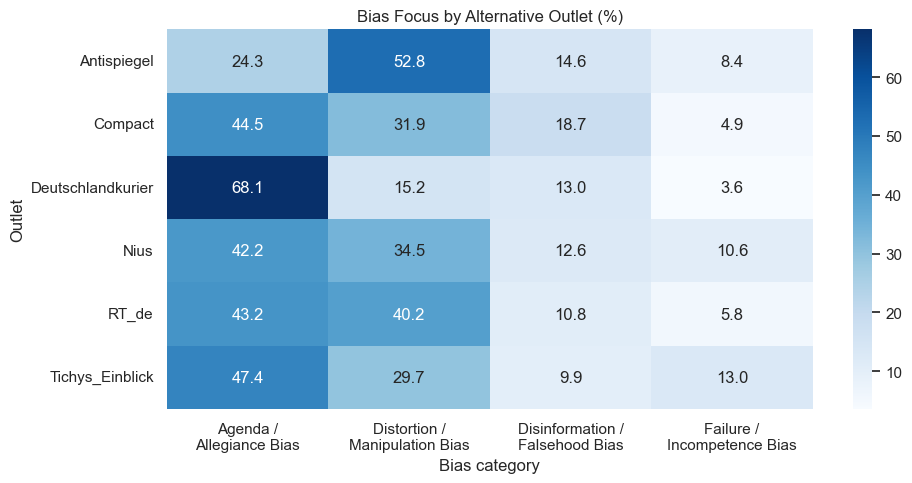

In [31]:
# Original categories in the data
bias_categories = [
    "POSITIONS-/PARTEILICHKEITS-BIAS",
    "VERZERRUNG/MANIPULATION",
    "DISINFORMATION/FALSCHDARSTELLUNG",
    "VERSAGEN/INKOMPETENZ",
]

# English labels only for display
category_labels = {
    "POSITIONS-/PARTEILICHKEITS-BIAS": "Agenda /\nAllegiance Bias",
    "VERZERRUNG/MANIPULATION": "Distortion /\nManipulation Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG": "Disinformation /\nFalsehood Bias",
    "VERSAGEN/INKOMPETENZ": "Failure /\nIncompetence Bias",
}

plot_df = df[
    (df["source"] != "Tagesschau") &
    (df["category"].isin(bias_categories))
].copy()

source_order = [
    s for s in [
        "Antispiegel", "Compact", "Deutschlandkurier",
        "Nius", "RT_de", "Tichys_Einblick"
    ]
    if s in plot_df["source"].unique()
]

bias_counts = pd.crosstab(plot_df["source"], plot_df["category"]).reindex(
    index=source_order,
    columns=bias_categories,
    fill_value=0,
)

bias_pct = (
    bias_counts
    .div(bias_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

# Rename columns only for plotting/display
bias_pct_plot = bias_pct.rename(columns=category_labels)

display(bias_counts)
display(bias_pct_plot)

plt.figure(figsize=(10, 5))
sns.heatmap(bias_pct_plot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Bias Focus by Alternative Outlet (%)")
plt.xlabel("Bias category")
plt.ylabel("Outlet")
plt.tight_layout()
plt.show()

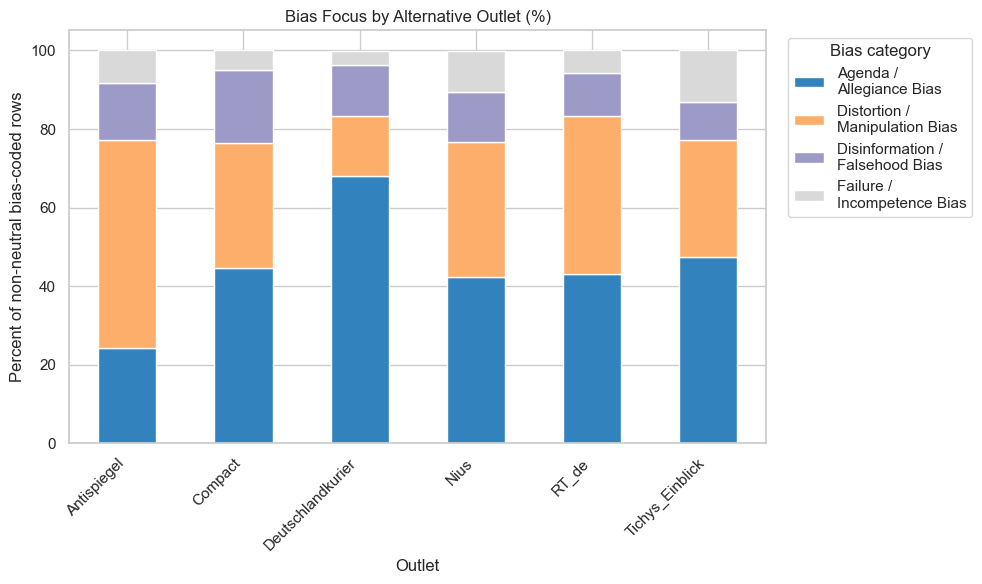

In [34]:
# English labels only for display
category_labels = {
    "POSITIONS-/PARTEILICHKEITS-BIAS": "Agenda /\nAllegiance Bias",
    "VERZERRUNG/MANIPULATION": "Distortion /\nManipulation Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG": "Disinformation /\nFalsehood Bias",
    "VERSAGEN/INKOMPETENZ": "Failure /\nIncompetence Bias",
}

bias_pct_plot = bias_pct.rename(columns=category_labels)

bias_pct_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20c"
)

plt.title("Bias Focus by Alternative Outlet (%)")
plt.xlabel("Outlet")
plt.ylabel("Percent of non-neutral bias-coded rows")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Bias category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


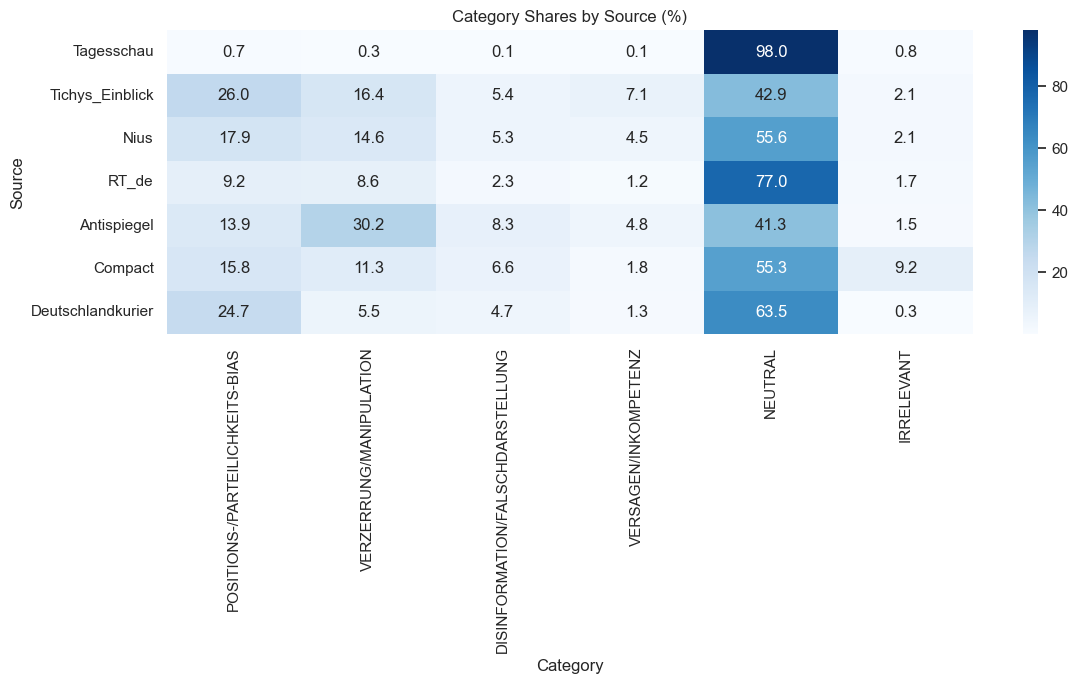

In [11]:
plt.figure(figsize=(12, 7))
sns.heatmap(category_by_source_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Category Shares by Source (%)")
plt.xlabel("Category")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


category,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ,IRRELEVANT
source,,,,,
Tichys_Einblick,594,373,124,163,49
Nius,362,296,108,91,42
RT_de,172,160,43,23,31
Antispiegel,75,163,45,26,8
Compact,81,58,34,9,47
Deutschlandkurier,94,21,18,5,1


category,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ,IRRELEVANT
source,,,,,
Tichys_Einblick,45.59,28.63,9.52,12.51,3.76
Nius,40.27,32.93,12.01,10.12,4.67
RT_de,40.09,37.30,10.02,5.36,7.23
Antispiegel,23.66,51.42,14.20,8.20,2.52
Compact,35.37,25.33,14.85,3.93,20.52
Deutschlandkurier,67.63,15.11,12.95,3.60,0.72


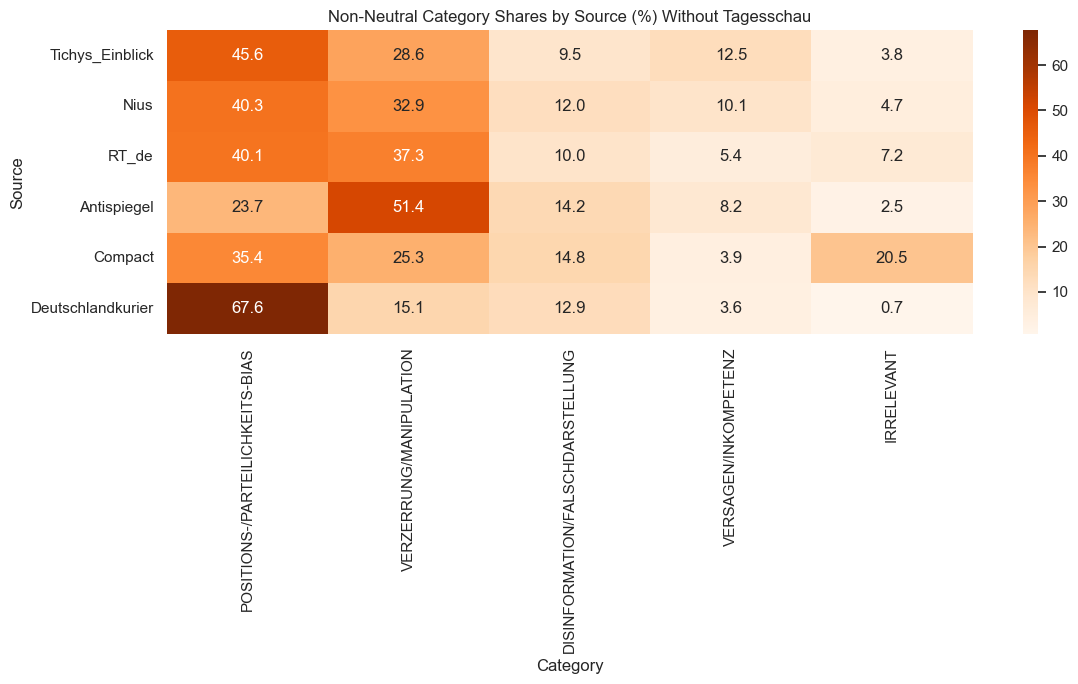

In [12]:
non_neutral_df = df[
    (df["category"] != "NEUTRAL") &
    (df["source"] != "Tagesschau")
].copy()

non_neutral_source_order = [s for s in source_order if s != "Tagesschau"]

non_neutral_counts = pd.crosstab(
    non_neutral_df["source"],
    non_neutral_df["category"],
).reindex(
    index=non_neutral_source_order,
    columns=[c for c in category_order if c != "NEUTRAL"],
    fill_value=0
)

non_neutral_pct = (
    non_neutral_counts
    .div(non_neutral_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

display(non_neutral_counts)
display(non_neutral_pct)

plt.figure(figsize=(12, 7))
sns.heatmap(non_neutral_pct, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Non-Neutral Category Shares by Source (%) Without Tagesschau")
plt.xlabel("Category")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


### Hit Text Exploration

Overall Hit Text Distribution

In [13]:
hit_text_counts = (
    df["hit_text"]
    .fillna("<<MISSING>>")
    .value_counts(dropna=False)
    .rename_axis("hit_text")
    .reset_index(name="frequency")
)

hit_text_counts["pct_overall"] = (hit_text_counts["frequency"] / len(df) * 100).round(2)

print(f"Total rows: {len(df):,}")
print(f"Unique hit_text values (including missing): {hit_text_counts.shape[0]:,}")
hit_text_counts.head(50)

Total rows: 11,973
Unique hit_text values (including missing): 941


,hit_text,frequency,pct_overall
0,Deutschlandfunk,1203,10.05
1,Spiegel,927,7.74
2,Reuters,689,5.75
3,ZDF,598,4.99
4,SWR,433,3.62
5,Politico,395,3.30
6,ARD,390,3.26
7,dpa,390,3.26
8,NDR,362,3.02
9,MDR,320,2.67


Hit Text Distirbution: Biased mentions

In [14]:
non_neutral_irrelevant_df = df[~df["category"].isin(["NEUTRAL", "IRRELEVANT"])].copy()

hit_text_counts = (
    non_neutral_irrelevant_df["hit_text"]
    .fillna("<<MISSING>>")
    .value_counts(dropna=False)
    .rename_axis("hit_text")
    .reset_index(name="frequency")
)

hit_text_counts["pct_overall"] = (hit_text_counts["frequency"] / len(non_neutral_irrelevant_df) * 100).round(2)

print(f"Total rows: {len(non_neutral_irrelevant_df):,}")
print(f"Unique hit_text values (including missing): {hit_text_counts.shape[0]:,}")
hit_text_counts.head(50)

Total rows: 3,192
Unique hit_text values (including missing): 645


,hit_text,frequency,pct_overall
0,Spiegel,383,12.00
1,ZDF,265,8.30
2,ARD,204,6.39
3,ÖRR,128,4.01
4,Tagesschau,103,3.23
5,ARD | ZDF,103,3.23
6,Markus Lanz,100,3.13
7,The European,96,3.01
8,taz,83,2.60
9,NDR,50,1.57


In [15]:
# Save current hit_text_counts to CSV
out_path = csv_path.parent / "hit_text_counts.csv"
hit_text_counts.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"Saved: {out_path}")


Saved: /Users/katinkakurz/projects/Thesis/2a_NER/outputs/hit_text_counts.csv


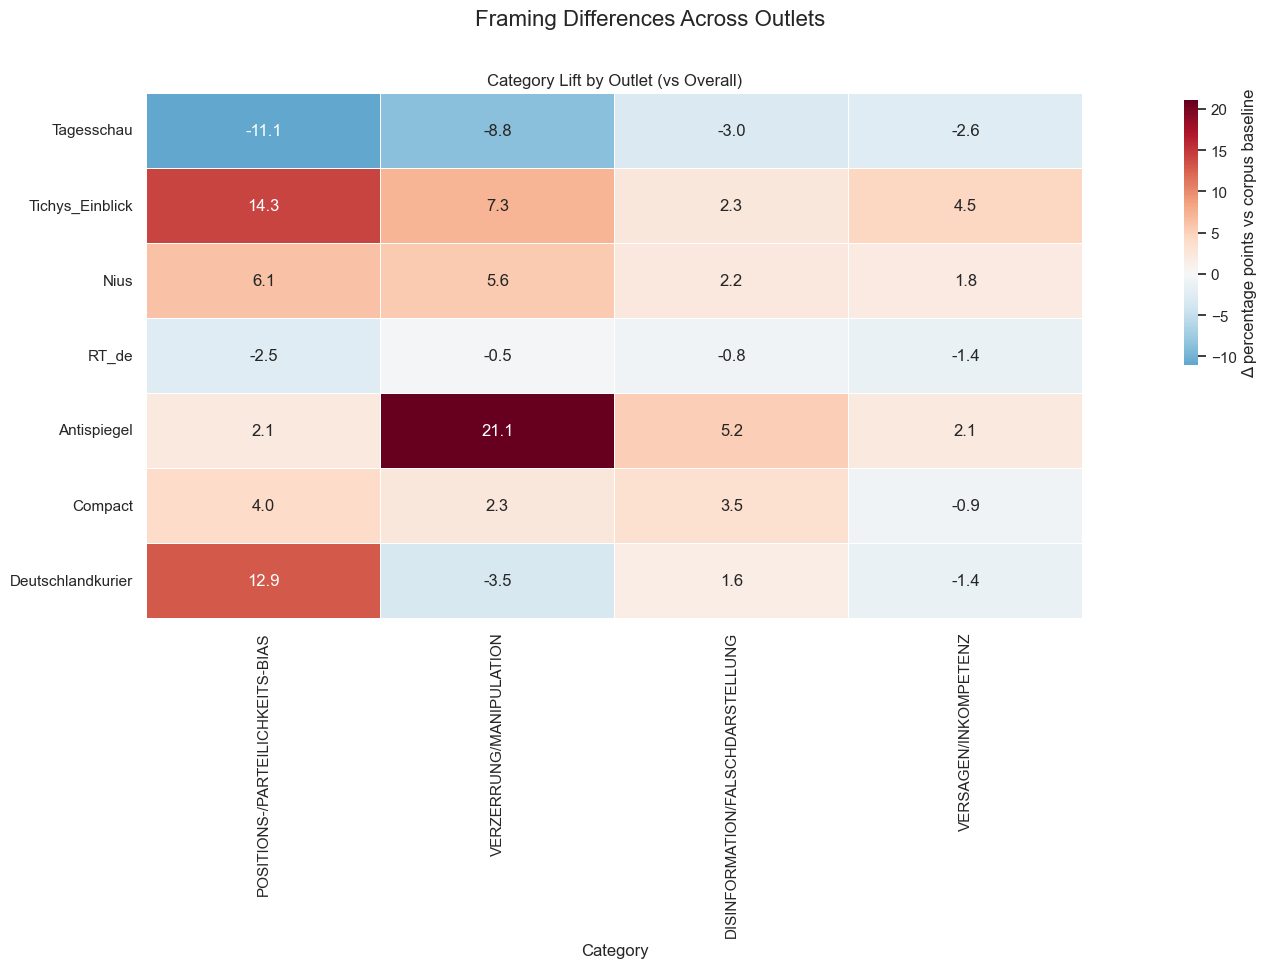

In [16]:
# Comparative outlet framing dashboard (cell 14)

focus_categories = [
    "POSITIONS-/PARTEILICHKEITS-BIAS",
    "VERZERRUNG/MANIPULATION",
    "DISINFORMATION/FALSCHDARSTELLUNG",
    "VERSAGEN/INKOMPETENZ",
]

# 3) Difference from corpus baseline in percentage points (all outlets)
baseline_pct = overall_category_counts.set_index("category")["pct"]
delta_pp = (
    category_by_source_pct.loc[source_order, focus_categories]
    .sub(baseline_pct[focus_categories], axis=1)
    .round(2)
)

fig, axes = plt.subplots(
    1, 3, figsize=(24, 7),
    gridspec_kw={"width_ratios": [1.0, 1.6, 1.6]}
)

# Panel C: Over/under-indexing vs overall baseline
sns.heatmap(
    delta_pp,
    annot=True, fmt=".1f", center=0, cmap="RdBu_r",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Δ percentage points vs corpus baseline"},
    ax=axes[2]
)
axes[2].set_title("Category Lift by Outlet (vs Overall)")
axes[2].set_xlabel("Category")
axes[2].set_ylabel("")

plt.suptitle("Framing Differences Across Outlets", y=1.02, fontsize=16)
plt.tight_layout()
for ax in axes[:2]:
    fig.delaxes(ax)

fig.set_size_inches(12, 7)
axes[2].set_position([0.08, 0.15, 0.78, 0.75])

plt.show()

# CLAUDE TEST

,entity,n_contexts
0,ARD,16
1,Deutschlandfunk,16
2,ZDF,14
3,NDR,14
4,ÖRR,14
5,Spiegel,12
6,Stern,11
7,FAZ,11
8,WDR,11
9,rbb,11


Top entities used for analysis:
['ARD', 'Deutschlandfunk', 'ZDF', 'ÖRR', 'NDR', 'Spiegel', 'FAZ', 'WDR', 'Stern', 'rbb', 'Tagesschau', 'Markus Lanz', 'BR', 'taz', 'Correctiv']


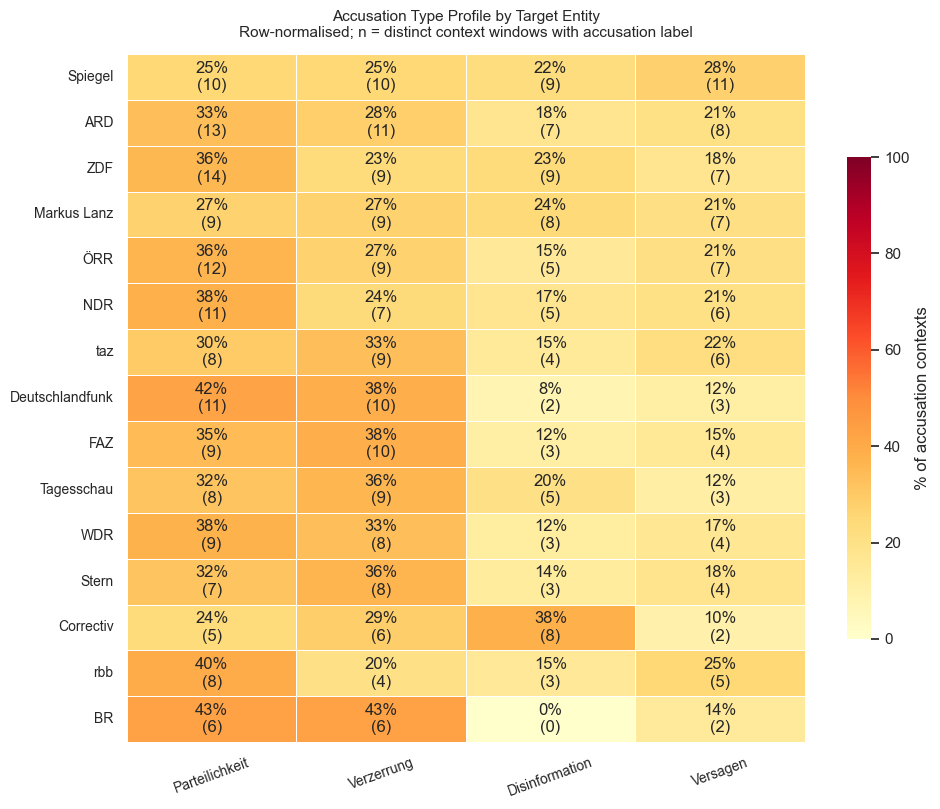

Neutral / irrelevant rate per entity (% of all contexts):


category,NEUTRAL,IRRELEVANT,POSITIONS-/PARTEILICHKEITS-BIAS,VERZERRUNG/MANIPULATION,DISINFORMATION/FALSCHDARSTELLUNG,VERSAGEN/INKOMPETENZ
entity,,,,,,
Deutschlandfunk,31.6,0.0,28.9,26.3,5.3,7.9
BR,30.4,8.7,26.1,26.1,0.0,8.7
NDR,29.3,0.0,26.8,17.1,12.2,14.6
rbb,25.9,0.0,29.6,14.8,11.1,18.5
WDR,25.0,0.0,28.1,25.0,9.4,12.5
Markus Lanz,21.7,6.5,19.6,19.6,17.4,15.2
FAZ,21.2,0.0,27.3,30.3,9.1,12.1
ARD,20.4,0.0,26.5,22.4,14.3,16.3
Tagesschau,19.4,0.0,25.8,29.0,16.1,9.7


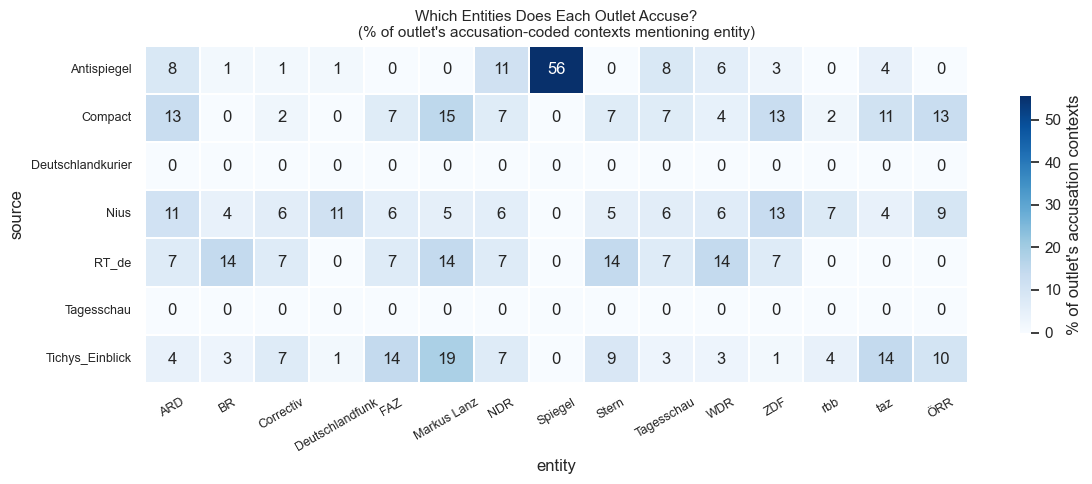

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# 0. Load
csv_path = Path("/Users/katinkakurz/projects/Thesis/2a_NER/outputs/framing_gpt_results.csv")
df = pd.read_csv(csv_path).copy()

# Basic cleanup
df["source"] = df["source"].fillna("unknown").astype(str).str.strip()
df["category"] = df["category"].fillna("missing").astype(str).str.strip()
df["hit_text"] = df["hit_text"].fillna("").astype(str).str.strip()

# Use the existing context id if present; otherwise build a stable fallback
if "context_idx" in df.columns:
    df["context_key"] = df["context_idx"].astype(str)
else:
    df["context_key"] = (
        df["row_id"].astype(str) + "||" + df["context_window"].fillna("").astype(str)
    )

# 1. Explode hit_text into one row per entity per context window
# hit_text looks like "ARD | Tagesschau | Spiegel"
df_exp = df.copy()
df_exp["entity"] = df_exp["hit_text"].str.split(r"\s*\|\s*")
df_exp = df_exp.explode("entity").reset_index(drop=True)
df_exp["entity"] = df_exp["entity"].fillna("").astype(str).str.strip()
df_exp = df_exp[df_exp["entity"] != ""].copy()

# 2. Constants
ACCUSATION_CATS = [
    "POSITIONS-/PARTEILICHKEITS-BIAS",
    "VERZERRUNG/MANIPULATION",
    "DISINFORMATION/FALSCHDARSTELLUNG",
    "VERSAGEN/INKOMPETENZ",
]
ALL_CATS = ACCUSATION_CATS + ["NEUTRAL", "IRRELEVANT"]

SHORT_LABELS = {
    "POSITIONS-/PARTEILICHKEITS-BIAS": "Parteilichkeit",
    "VERZERRUNG/MANIPULATION": "Verzerrung",
    "DISINFORMATION/FALSCHDARSTELLUNG": "Disinformation",
    "VERSAGEN/INKOMPETENZ": "Versagen",
}

OUTLET_ORDER = [
    s for s in [
        "Antispiegel", "Compact", "Deutschlandkurier",
        "Nius", "RT_de", "Tagesschau", "Tichys_Einblick"
    ]
    if s in df_exp["source"].unique()
]

# 3. Entity frequency table
entity_totals = (
    df_exp.groupby("entity")["context_key"]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_contexts")
    .reset_index()
)

display(entity_totals.head(30))

# 4. Filter: accusation rows only, min frequency threshold
MIN_CONTEXTS = 5

df_acc = df_exp[df_exp["category"].isin(ACCUSATION_CATS)].copy()

# Deduplicate: same context window can only contribute once per entity/category
df_acc_dedup = df_acc.drop_duplicates(subset=["context_key", "entity", "category"])

top_entities = (
    df_acc_dedup.groupby("entity")["context_key"]
    .nunique()
    .loc[lambda s: s >= MIN_CONTEXTS]
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

print("Top entities used for analysis:")
print(top_entities)

# 5. Build entity × category matrix
matrix = (
    df_acc_dedup[df_acc_dedup["entity"].isin(top_entities)]
    .groupby(["entity", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ACCUSATION_CATS, fill_value=0)
)

matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]

matrix_pct = matrix.div(matrix.sum(axis=1), axis=0) * 100
matrix_pct.columns = [SHORT_LABELS[c] for c in matrix_pct.columns]

# 6. Heatmap
annot_labels = matrix_pct.copy().astype(str)
for col_short, col_full in zip(matrix_pct.columns, ACCUSATION_CATS):
    annot_labels[col_short] = (
        matrix_pct[col_short].map("{:.0f}%".format)
        + "\n("
        + matrix[col_full].astype(str)
        + ")"
    )

fig, ax = plt.subplots(figsize=(10, max(4, len(matrix_pct) * 0.55)))
sns.heatmap(
    matrix_pct,
    annot=annot_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    vmin=0, vmax=100,
    cbar_kws={"label": "% of accusation contexts", "shrink": 0.7},
    ax=ax,
)
ax.set_title(
    "Accusation Type Profile by Target Entity\n"
    "Row-normalised; n = distinct context windows with accusation label",
    fontsize=11,
    pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10, rotation=20)
ax.tick_params(axis="y", labelsize=10, rotation=0)
plt.tight_layout()
plt.show()

# 7. Neutral / irrelevant rate per entity
all_dedup = df_exp.drop_duplicates(subset=["context_key", "entity", "category"])

neutral_rate = (
    all_dedup[all_dedup["entity"].isin(top_entities)]
    .groupby("entity")["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("pct")
    .reset_index()
    .pivot(index="entity", columns="category", values="pct")
    .fillna(0)
)

neutral_rate = neutral_rate.reindex(
    columns=["NEUTRAL", "IRRELEVANT"] + ACCUSATION_CATS,
    fill_value=0
).sort_values("NEUTRAL", ascending=False)

print("Neutral / irrelevant rate per entity (% of all contexts):")
display(neutral_rate)

# 8. Outlet × entity accusation rate
outlet_entity = (
    df_acc_dedup[df_acc_dedup["entity"].isin(top_entities)]
    .groupby(["source", "entity"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=OUTLET_ORDER, fill_value=0)
)

outlet_entity_pct = outlet_entity.div(outlet_entity.sum(axis=1), axis=0) * 100
outlet_entity_pct = outlet_entity_pct.fillna(0)

fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.heatmap(
    outlet_entity_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "% of outlet's accusation contexts", "shrink": 0.7},
    ax=ax2,
)
ax2.set_title(
    "Which Entities Does Each Outlet Accuse?\n"
    "(% of outlet's accusation-coded contexts mentioning entity)",
    fontsize=11,
)
ax2.tick_params(axis="x", labelsize=9, rotation=30)
ax2.tick_params(axis="y", labelsize=9, rotation=0)
plt.tight_layout()
plt.show()


# Grouping Hit Text

In [21]:
focus_df = df[~df["category"].isin(["NEUTRAL", "IRRELEVANT"])].copy()

# 3. Explode hit_text into one row per entity
focus_df["entity"] = focus_df["hit_text"].fillna("").astype(str).str.split(r"\s*\|\s*")
focus_df = focus_df.explode("entity").reset_index(drop=True)
focus_df["entity"] = focus_df["entity"].fillna("").astype(str).str.strip()
focus_df = focus_df[focus_df["entity"] != ""].copy()

# 4. Canonicalize obvious aliases
canonical_map = {
    "FAZ": "Frankfurter Allgemeine Zeitung",
    "Frankfurter Allgemeine Zeitung": "Frankfurter Allgemeine Zeitung",
    "SZ": "Süddeutsche Zeitung",
    "Süddeutsche Zeitung": "Süddeutsche Zeitung",
    "Bild-Zeitung": "Bild",
    "Bild": "Bild",
    "Das Erste": "ARD",
    "ARD": "ARD",
    "Tagesschau": "Tagesschau",
    "ÖRR": "ÖRR",
}
focus_df["entity_canonical"] = focus_df["entity"].replace(canonical_map)

In [22]:
def assign_entity_group(entity):
    if entity in {
        "ARD", "ZDF", "Tagesschau", "Deutschlandfunk",
        "NDR", "NDR Info", "WDR", "SWR", "MDR", "rbb", "BR", "ÖRR"
    }:
        return "ÖRR outlets"

    if entity in {"Markus Lanz", "Jan Böhmermann", "Caren Miosga"}:
        return "ÖRR personalities"

    if entity in {
        "Spiegel", "Bild", "Frankfurter Allgemeine Zeitung", "Süddeutsche Zeitung",
        "taz", "Tagesspiegel", "Berliner Zeitung", "Handelsblatt",
        "Stern", "Rheinische Post"
    }:
        return "Legacy print / magazines"

    if entity == "Correctiv":
        return "Fact-checking / Correctiv"

    if entity in {"Reuters", "dpa", "Politico", "RND", "Euronews"}:
        return "Aggregators / agencies"

    if entity in {"The European", "RTL"}:
        return "Private / digital outlets"

    if entity in {
        "Lügenpresse", "Systemmedien", "Staatsmedien", "Staatsfunk", "Staatssender",
        "Mainstreammedien", "Mainstreampresse", "Gleichschaltung",
        "Haltungsmedien", "Haltungsjournalisten", "Haltungsjournalismus",
        "Altmedien", "Gesternmedien", "Regierungsmedien", "Linkspresse",
        "Medienpropaganda", "Propagandasender", "Propagandamaschine",
        "Propagandamedien"
    }: return "Pejorative collective terms"
        
    if entity in {
    "Qualitätsmedien",
    "Qualitätspresse",
    "Qualitätsjournalismus",
    "Qualitätsjournalisten",
    }: return "Qualitäts collective terms"

    if entity in {"Alternativmedien"}:
        return "Alternative media labels"

    return "Other / inspect"


entity_group,ÖRR outlets,ÖRR personalities,Legacy print / magazines,Fact-checking / Correctiv,Aggregators / agencies,Private / digital outlets,Pejorative collective terms,Qualitäts collective terms,Alternative media labels,Other / inspect
source,,,,,,,,,,
Antispiegel,21,0,286,1,10,0,6,8,0,0
Compact,48,10,78,3,5,10,46,1,7,0
Deutschlandkurier,84,26,40,10,5,5,17,1,0,0
Nius,626,107,203,28,19,55,33,6,1,1
RT_de,222,35,126,14,50,3,36,7,0,4
Tagesschau,19,0,15,0,4,1,20,0,1,0
Tichys_Einblick,723,178,355,39,29,60,107,23,0,4


entity_group,ÖRR outlets,ÖRR personalities,Legacy print / magazines,Fact-checking / Correctiv,Aggregators / agencies,Private / digital outlets,Pejorative collective terms,Qualitäts collective terms,Alternative media labels,Other / inspect
source,,,,,,,,,,
Antispiegel,6.33,0.00,86.14,0.30,3.01,0.00,1.81,2.41,0.00,0.00
Compact,23.08,4.81,37.50,1.44,2.40,4.81,22.12,0.48,3.37,0.00
Deutschlandkurier,44.68,13.83,21.28,5.32,2.66,2.66,9.04,0.53,0.00,0.00
Nius,58.02,9.92,18.81,2.59,1.76,5.10,3.06,0.56,0.09,0.09
RT_de,44.67,7.04,25.35,2.82,10.06,0.60,7.24,1.41,0.00,0.80
Tagesschau,31.67,0.00,25.00,0.00,6.67,1.67,33.33,0.00,1.67,0.00
Tichys_Einblick,47.63,11.73,23.39,2.57,1.91,3.95,7.05,1.52,0.00,0.26


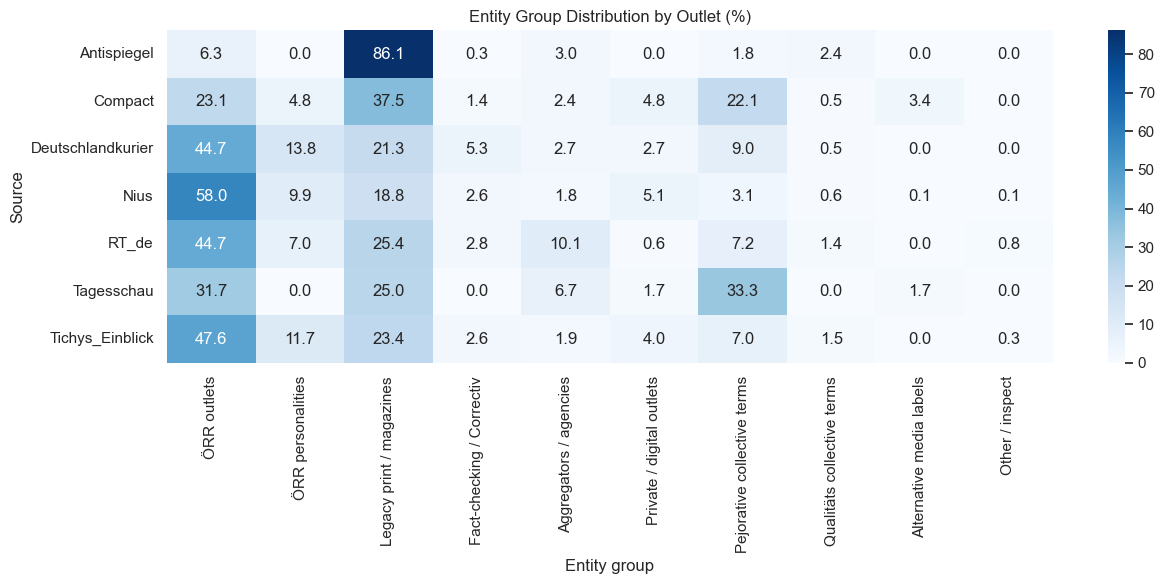

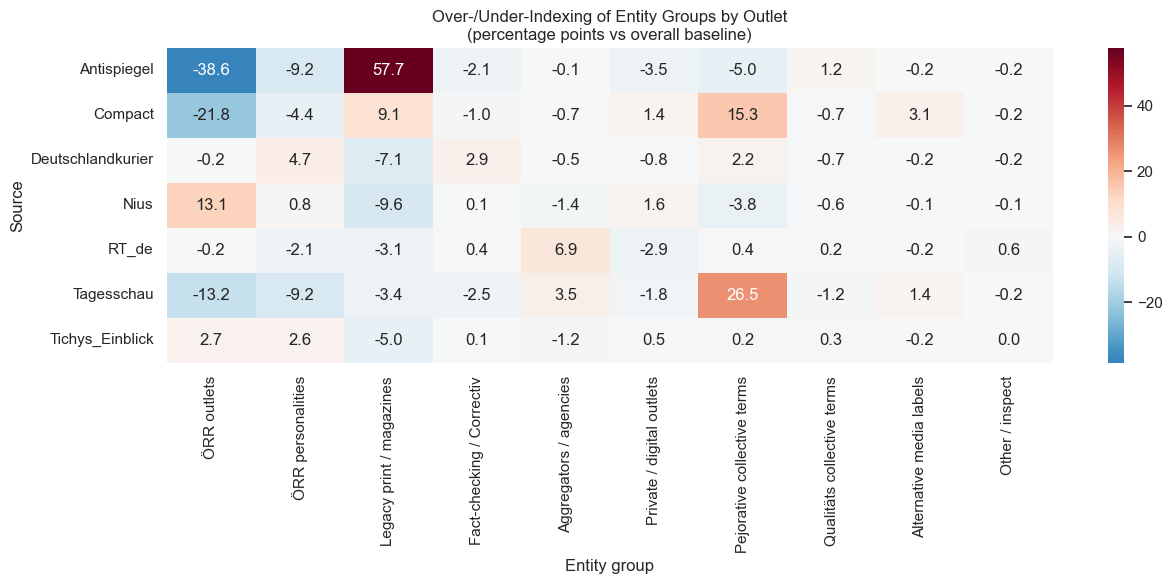

In [23]:
focus_df["entity_group"] = focus_df["entity_canonical"].apply(assign_entity_group)

# 6. Stable context key and deduplication
if "context_idx" in focus_df.columns:
    focus_df["context_key"] = focus_df["row_id"].astype(str) + "||" + focus_df["context_idx"].astype(str)
else:
    focus_df["context_key"] = (
        focus_df["row_id"].astype(str) + "||" + focus_df["context_window"].fillna("").astype(str)
    )

# One outlet-context-entity_group combination should count once
group_df = focus_df.drop_duplicates(subset=["source", "context_key", "entity_group"]).copy()

# 7. Order
source_order = [
    s for s in [
        "Antispiegel", "Compact", "Deutschlandkurier",
        "Nius", "RT_de", "Tagesschau", "Tichys_Einblick"
    ]
    if s in group_df["source"].unique()
]

group_order = [
    "ÖRR outlets",
    "ÖRR personalities",
    "Legacy print / magazines",
    "Fact-checking / Correctiv",
    "Aggregators / agencies",
    "Private / digital outlets",
    "Pejorative collective terms",
    "Qualitäts collective terms",
    "Alternative media labels",
    "Other / inspect",
]

group_order = [g for g in group_order if g in group_df["entity_group"].unique()]

# 8. Counts and percentages
group_counts = pd.crosstab(group_df["source"], group_df["entity_group"]).reindex(
    index=source_order,
    columns=group_order,
    fill_value=0,
)

group_pct = (
    group_counts
    .div(group_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

display(group_counts)
display(group_pct)

# 9. Heatmap of within-outlet percentages
plt.figure(figsize=(13, 6))
sns.heatmap(group_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Entity Group Distribution by Outlet (%)")
plt.xlabel("Entity group")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

# 10. Difference from overall baseline in percentage points
overall_group_pct = (
    group_df["entity_group"]
    .value_counts(normalize=True)
    .reindex(group_order, fill_value=0)
    .mul(100)
)

delta_pp = group_pct.sub(overall_group_pct, axis=1).round(2)

plt.figure(figsize=(13, 6))
sns.heatmap(delta_pp, annot=True, fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Over-/Under-Indexing of Entity Groups by Outlet\n(percentage points vs overall baseline)")
plt.xlabel("Entity group")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

entity_group,ÖRR outlets,ÖRR personalities,Legacy print / magazines,Fact-checking / Correctiv,Aggregators / agencies,Private / digital outlets,Pejorative collective terms,Qualitäts collective terms,Alternative media labels,Other / inspect
source,,,,,,,,,,
Antispiegel,21,0,286,1,10,0,6,8,0,0
Compact,48,10,78,3,5,10,46,1,7,0
Deutschlandkurier,84,26,40,10,5,5,17,1,0,0
Nius,626,107,203,28,19,55,33,6,1,1
RT_de,222,35,126,14,50,3,36,7,0,4
Tichys_Einblick,723,178,355,39,29,60,107,23,0,4


entity_group,ÖRR outlets,ÖRR personalities,Legacy print / magazines,Fact-checking / Correctiv,Aggregators / agencies,Private / digital outlets,Pejorative collective terms,Qualitäts collective terms,Alternative media labels,Other / inspect
source,,,,,,,,,,
Antispiegel,6.33,0.00,86.14,0.30,3.01,0.00,1.81,2.41,0.00,0.00
Compact,23.08,4.81,37.50,1.44,2.40,4.81,22.12,0.48,3.37,0.00
Deutschlandkurier,44.68,13.83,21.28,5.32,2.66,2.66,9.04,0.53,0.00,0.00
Nius,58.02,9.92,18.81,2.59,1.76,5.10,3.06,0.56,0.09,0.09
RT_de,44.67,7.04,25.35,2.82,10.06,0.60,7.24,1.41,0.00,0.80
Tichys_Einblick,47.63,11.73,23.39,2.57,1.91,3.95,7.05,1.52,0.00,0.26


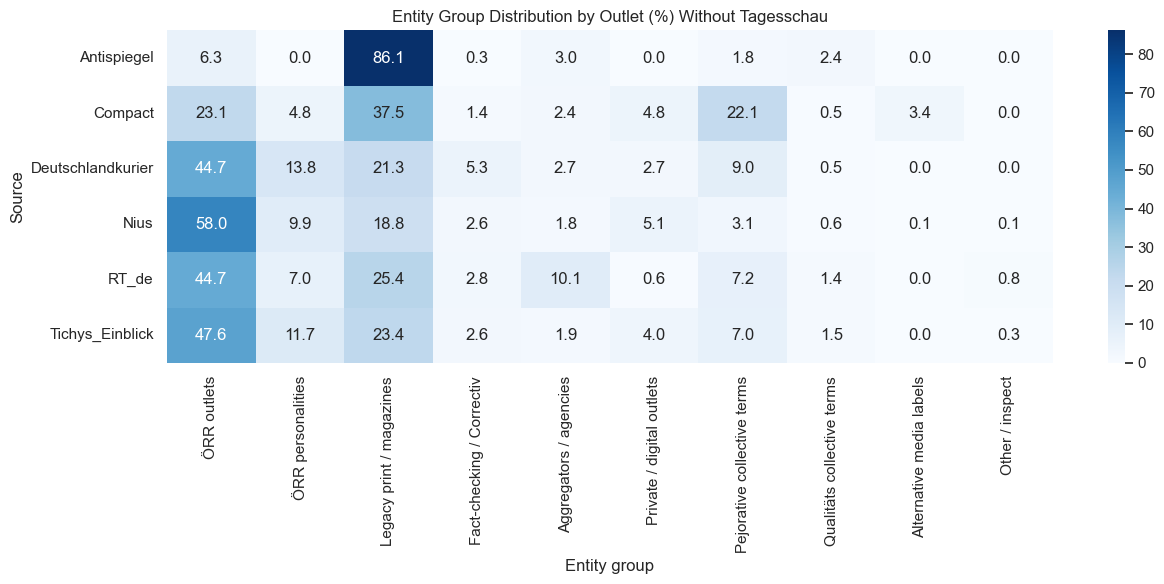

In [24]:
group_df_no_tagesschau = group_df[group_df["source"] != "Tagesschau"].copy()

source_order_no_tagesschau = [s for s in source_order if s != "Tagesschau"]

group_counts_no_tagesschau = pd.crosstab(
    group_df_no_tagesschau["source"],
    group_df_no_tagesschau["entity_group"]
).reindex(
    index=source_order_no_tagesschau,
    columns=group_order,
    fill_value=0,
)

group_pct_no_tagesschau = (
    group_counts_no_tagesschau
    .div(group_counts_no_tagesschau.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

display(group_counts_no_tagesschau)
display(group_pct_no_tagesschau)

plt.figure(figsize=(13, 6))
sns.heatmap(group_pct_no_tagesschau, annot=True, fmt=".1f", cmap="Blues")
plt.title("Entity Group Distribution by Outlet (%) Without Tagesschau")
plt.xlabel("Entity group")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


raw_hit,ZDF,ARD,Spiegel,ÖRR,Tagesschau,Markus Lanz,taz,NDR,FAZ,Jan Böhmermann,The European,Deutschlandfunk,Correctiv,WDR,Stern,Süddeutsche Zeitung,Tagesspiegel,SWR,SZ,Bild
source,,,,,,,,,,,,,,,,,,,,
Antispiegel,2,7,273,0,7,0,3,9,0,0,0,1,1,4,0,7,0,0,0,5
Compact,13,19,34,6,9,8,15,11,5,2,8,0,3,2,5,3,5,0,1,12
Deutschlandkurier,55,30,13,3,12,4,9,9,3,22,4,1,10,2,0,8,9,1,1,0
Nius,339,253,70,72,86,41,52,58,35,59,50,63,28,34,30,22,16,10,23,4
RT_de,77,61,50,12,54,17,12,18,16,15,2,4,14,21,6,6,13,23,5,16
Tichys_Einblick,304,266,112,194,82,136,77,43,75,33,54,31,39,28,41,21,23,25,25,16


raw_hit,ZDF,ARD,Spiegel,ÖRR,Tagesschau,Markus Lanz,taz,NDR,FAZ,Jan Böhmermann,The European,Deutschlandfunk,Correctiv,WDR,Stern,Süddeutsche Zeitung,Tagesspiegel,SWR,SZ,Bild
source,,,,,,,,,,,,,,,,,,,,
Antispiegel,0.57,1.99,77.78,0.00,1.99,0.00,0.85,2.56,0.00,0.00,0.00,0.28,0.28,1.14,0.00,1.99,0.00,0.00,0.00,1.42
Compact,5.63,8.23,14.72,2.60,3.90,3.46,6.49,4.76,2.16,0.87,3.46,0.00,1.30,0.87,2.16,1.30,2.16,0.00,0.43,5.19
Deutschlandkurier,24.23,13.22,5.73,1.32,5.29,1.76,3.96,3.96,1.32,9.69,1.76,0.44,4.41,0.88,0.00,3.52,3.96,0.44,0.44,0.00
Nius,22.50,16.79,4.64,4.78,5.71,2.72,3.45,3.85,2.32,3.92,3.32,4.18,1.86,2.26,1.99,1.46,1.06,0.66,1.53,0.27
RT_de,13.07,10.36,8.49,2.04,9.17,2.89,2.04,3.06,2.72,2.55,0.34,0.68,2.38,3.57,1.02,1.02,2.21,3.90,0.85,2.72
Tichys_Einblick,16.01,14.01,5.90,10.22,4.32,7.16,4.05,2.26,3.95,1.74,2.84,1.63,2.05,1.47,2.16,1.11,1.21,1.32,1.32,0.84


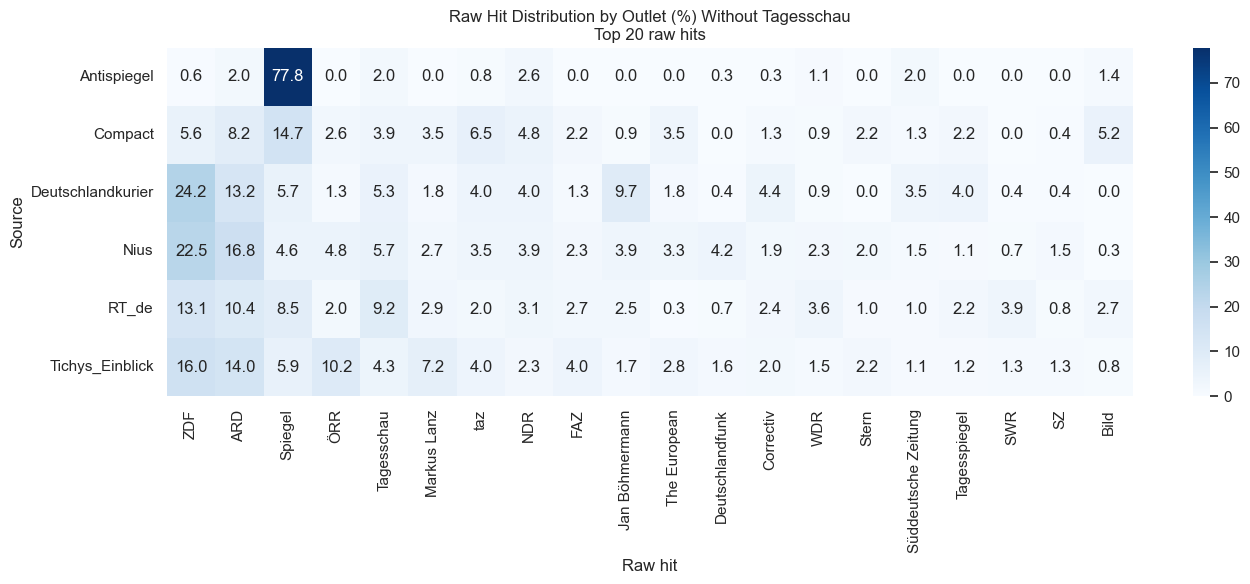

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Start from the full framing results df
raw_hit_df = df.copy()

# Keep only non-neutral / non-irrelevant rows and exclude Tagesschau
raw_hit_df = raw_hit_df[
    (~raw_hit_df["category"].isin(["NEUTRAL", "IRRELEVANT"])) &
    (raw_hit_df["source"] != "Tagesschau")
].copy()

# Build a stable context key
if "context_idx" in raw_hit_df.columns:
    raw_hit_df["context_key"] = (
        raw_hit_df["row_id"].astype(str) + "||" + raw_hit_df["context_idx"].astype(str)
    )
else:
    raw_hit_df["context_key"] = (
        raw_hit_df["row_id"].astype(str) + "||" + raw_hit_df["context_window"].fillna("").astype(str)
    )

# Split hit_text into raw hit words
raw_hit_df["raw_hit"] = raw_hit_df["hit_text"].fillna("").astype(str).str.split(r"\s*\|\s*")
raw_hit_df = raw_hit_df.explode("raw_hit").reset_index(drop=True)
raw_hit_df["raw_hit"] = raw_hit_df["raw_hit"].fillna("").astype(str).str.strip()
raw_hit_df = raw_hit_df[raw_hit_df["raw_hit"] != ""].copy()

# Deduplicate: same outlet-context-hit should count once
raw_hit_df = raw_hit_df.drop_duplicates(subset=["source", "context_key", "raw_hit"]).copy()

source_order_no_tagesschau = [
    s for s in [
        "Antispiegel", "Compact", "Deutschlandkurier",
        "Nius", "RT_de", "Tichys_Einblick"
    ]
    if s in raw_hit_df["source"].unique()
]

# Counts for all raw hits
raw_hit_counts = pd.crosstab(
    raw_hit_df["source"],
    raw_hit_df["raw_hit"]
).reindex(
    index=source_order_no_tagesschau,
    fill_value=0
)

# Percentages within each outlet
raw_hit_pct = (
    raw_hit_counts
    .div(raw_hit_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

# Keep top raw hits for visualization
TOP_N_HITS = 20
top_hits = raw_hit_counts.sum(axis=0).sort_values(ascending=False).head(TOP_N_HITS).index.tolist()

raw_hit_counts_top = raw_hit_counts[top_hits]
raw_hit_pct_top = raw_hit_pct[top_hits]

display(raw_hit_counts_top)
display(raw_hit_pct_top)

plt.figure(figsize=(14, 6))
sns.heatmap(raw_hit_pct_top, annot=True, fmt=".1f", cmap="Blues")
plt.title(f"Raw Hit Distribution by Outlet (%) Without Tagesschau\nTop {TOP_N_HITS} raw hits")
plt.xlabel("Raw hit")
plt.ylabel("Source")
plt.tight_layout()
plt.show()
